# TP1

Alumno: Victor Gabriel Peralta

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- PARTE 1: Algoritmo White Patch ---

def white_patch(image):
    # Separar los canales BGR (OpenCV usa BGR por defecto como se reviso en clase)
    channels = cv2.split(image)
    out_channels = []
    
    for channel in channels:
        
        max_val = np.max(channel)
   
        if max_val > 0:
            rescaled = (channel.astype(np.float32) * 255 / max_val).clip(0, 255)
            out_channels.append(rescaled.astype(np.uint8))
        else:
            out_channels.append(channel)
            
    return cv2.merge(out_channels)

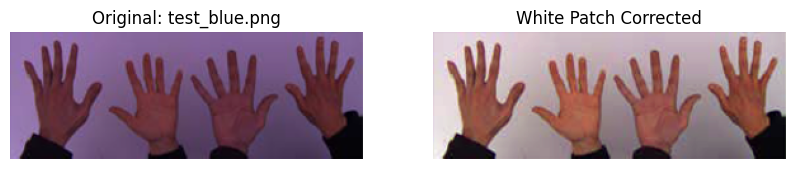

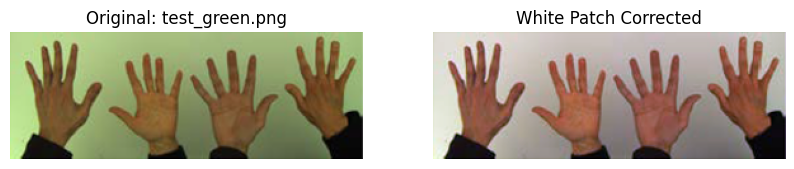

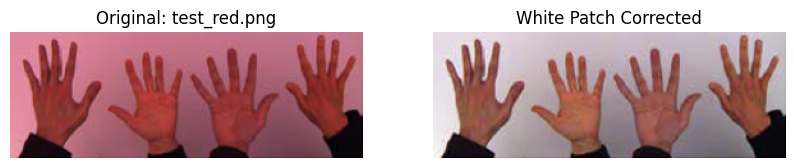

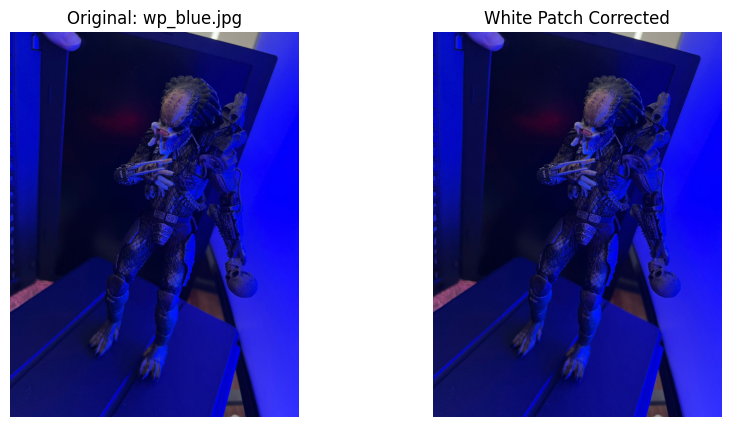

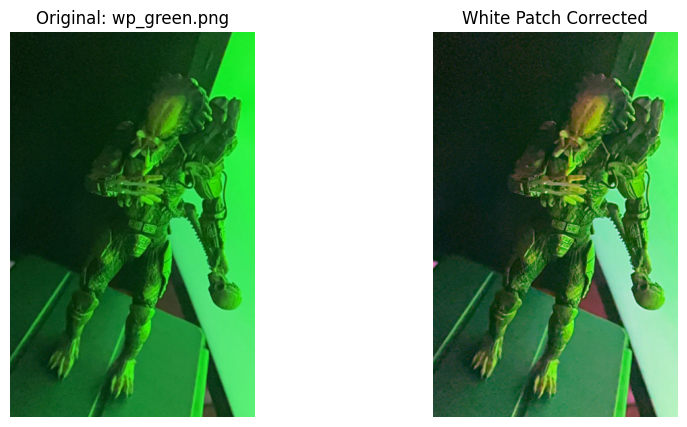

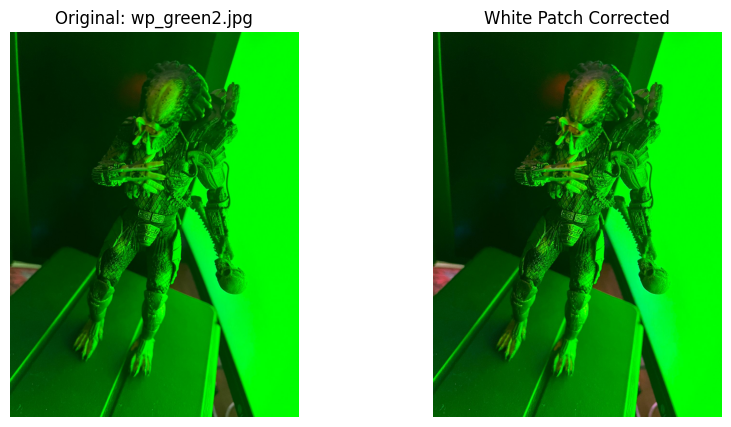

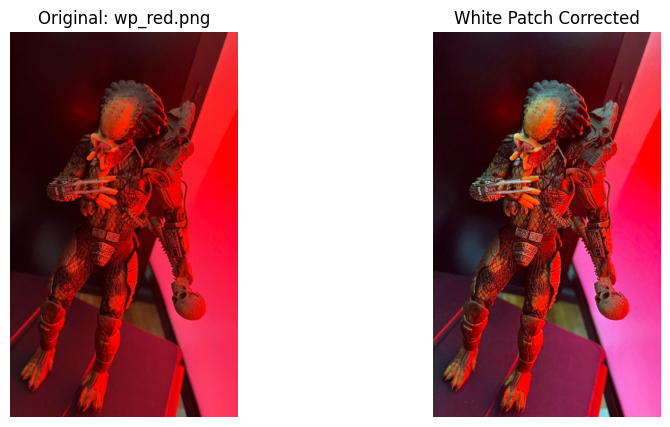

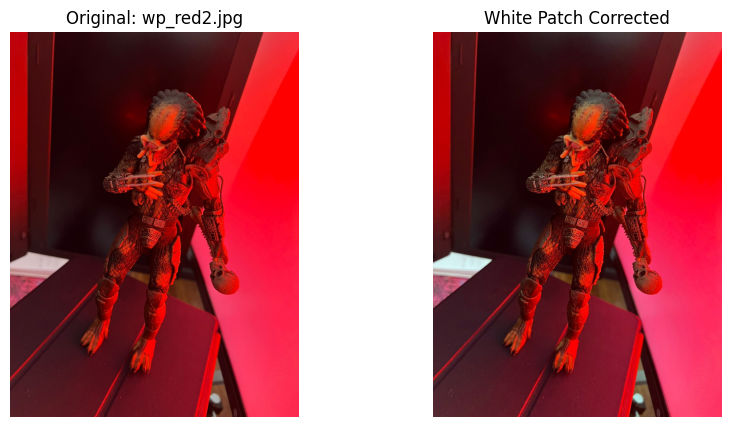

In [22]:
# Configuración de ruta y carga de imágenes
folder_path = r'TP1/white_patch/'
images = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

for img_name in images:
    path = os.path.join(folder_path, img_name)
    img = cv2.imread(path)
    
    if img is None: continue
    
    # Aplicar algoritmo
    img_corrected = white_patch(img)
    
    # Visualización (Convertimos BGR a RGB para Matplotlib)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Original: {img_name}")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("White Patch Corrected")
    plt.imshow(cv2.cvtColor(img_corrected, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.show()

El algoritmo funciona bajo la hipótesis de que en la imagen existe al menos un objeto que es originalmente blanco (o gris neutro muy claro).

Posibles Fallas:
- Falla por Iluminación Monocromática: Cuando la luz es de un color primario muy saturado (como los casos azul/rojo/verde neón), el algoritmo no puede recuperar los colores originales porque la información de los otros canales restantes es casi nula o puro ruido. El White Patch asume que hay una mezcla de colores que "suman" blanco, pero aquí no la hay.
- Brillos Especulares (Glints): Si hay un reflejo metálico o un "charco" de luz blanca pura en un objeto que no es blanco, el algoritmo usará ese punto como referencia. Esto causará que el resto de la imagen se vea subexpuesta (oscura), ya que el resto de los píxeles tendrán valores muy bajos en comparación con el brillo.
- Ausencia de Blanco Real: Si fotografías una pared roja bajo luz roja, el algoritmo forzará a que el rojo más intenso se convierta en blanco. Esto destruye la fidelidad del color, creando una imagen con colores lavados o irreales.
- Ruido en Altas Luces: Si un solo píxel tiene un valor de ruido muy alto ($255$) debido a un error del sensor, el algoritmo se "engaña" y no escala correctamente el resto de la imagen.

<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
C:\Users\peral\AppData\Local\Temp\ipykernel_34620\3944789238.py:6: SyntaxWarning: invalid escape sequence '\i'
  img1 = cv2.imread('TP1\img1_tp.png', cv2.IMREAD_GRAYSCALE)
C:\Users\peral\AppData\Local\Temp\ipykernel_34620\3944789238.py:7: SyntaxWarning: invalid escape sequence '\i'
  img2 = cv2.imread('TP1\img2_tp.png', cv2.IMREAD_GRAYSCALE)


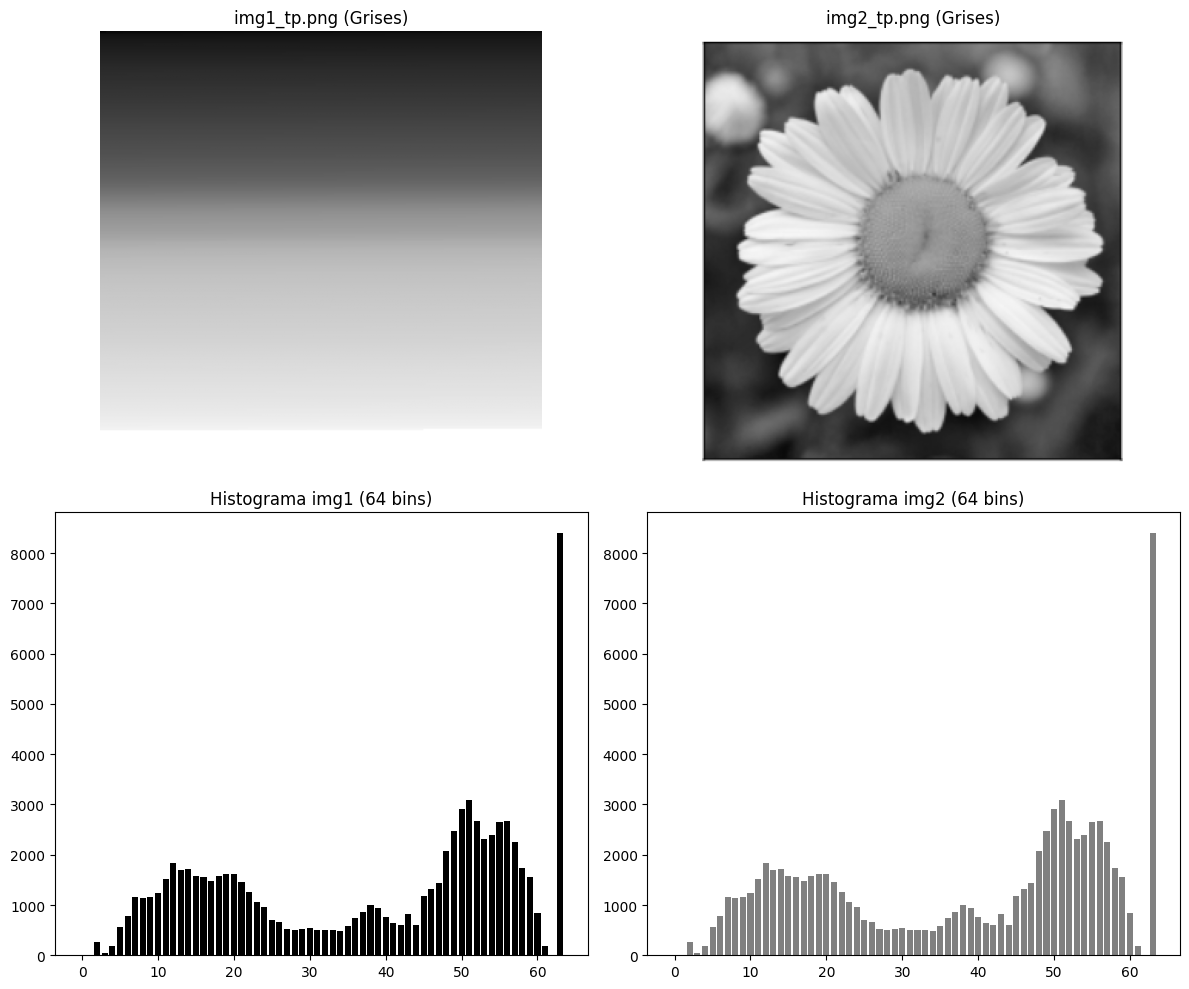

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Leer las imágenes en escala de grises
img1 = cv2.imread('TP1\img1_tp.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('TP1\img2_tp.png', cv2.IMREAD_GRAYSCALE)

# Verificar si las imágenes cargaron correctamente
if img1 is None or img2 is None:
    print("Error: No se encontraron los archivos img1_tp.png o img2_tp.png")
else:
    # 2. Configuración de Bins (64 es un buen balance entre detalle y generalización)
    n_bins = 64 
    
    # Calcular histogramas
    # calcHist(imágenes, canales, máscara, tamaño_hist, rango)
    hist1 = cv2.calcHist([img1], [0], None, [n_bins], [0, 256])
    hist2 = cv2.calcHist([img2], [0], None, [n_bins], [0, 256])

    # Visualización
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # Mostrar Imágenes
    axs[0, 0].imshow(img1, cmap='gray')
    axs[0, 0].set_title('img1_tp.png (Grises)')
    axs[0, 0].axis('off')

    axs[0, 1].imshow(img2, cmap='gray')
    axs[0, 1].set_title('img2_tp.png (Grises)')
    axs[0, 1].axis('off')

    # Graficar Histogramas
    axs[1, 0].bar(range(n_bins), hist1.ravel(), color='black')
    axs[1, 0].set_title(f'Histograma img1 ({n_bins} bins)')
    
    axs[1, 1].bar(range(n_bins), hist2.ravel(), color='gray')
    axs[1, 1].set_title(f'Histograma img2 ({n_bins} bins)')

    plt.tight_layout()
    plt.show()

Como se puede ver, los histogramas de la izquierda (el degradado) y la derecha (la flor) son prácticamente idénticos. Esto sucede porque ambas imágenes contienen exactamente la misma cantidad de píxeles oscuros, medios y claros, solo que organizados de forma distinta.

Lo que observamos es una pérdida total de información espacial.

- Imagen 1 (Degradado): Los píxeles están ordenados de forma suave y matemática desde el negro al blanco.

- Imagen 2 (Flor): Los mismos valores de intensidad están organizados para formar estructuras complejas (pétalos, sombras, centro de la flor).

Esto demuestra que el histograma describe el "qué" (qué colores/tonos hay) pero no el "dónde" (cómo se distribuyen).

Por lo que, los histogramas no son suficientes por sí solos para tareas de clasificación de objetos complejos o detección. Sin embargo, son excelentes como características complementarias:

- Contexto: Pueden ayudar al modelo a entender si la foto fue tomada de noche o de día.

- Segmentación: Son útiles para determinar umbrales (thresholds) de separación de fondo y figura.
